In [34]:
pip install lightkurve pandas matplotlib --quiet

In [35]:
import pandas as pd #data analysis library loads ASTAP .CSV to strucutred table (DataFrame)
import lightkurve as lk # Time series astrophotometry
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from scipy.stats import chi2

Variable star clipped indices: [0 1]
Check star clipped indices: []
Variable: kept 10/12 bins (min 3 pts/bin)
Check: kept 11/13 bins (min 3 pts/bin)
min_err_v: 0.0023, max_err_v: 0.0037
min_err_k: 0.003, max_err_k 0.0044
Variable Star reduced chi^2 = 11.25
Check Star reduced chi^2 = 3.2
Variable Star p-value = 8.86858942892822e-18
Check Star p-value = 0.00040724493827328987
Rescaled Variable Star reduced chi^2 = 3.52
Rescaled Check Star reduced chi^2    = 1.0
Rescaled Variable Star p-value = 0.000226
Rescaled Check Star p-value    = 0.44


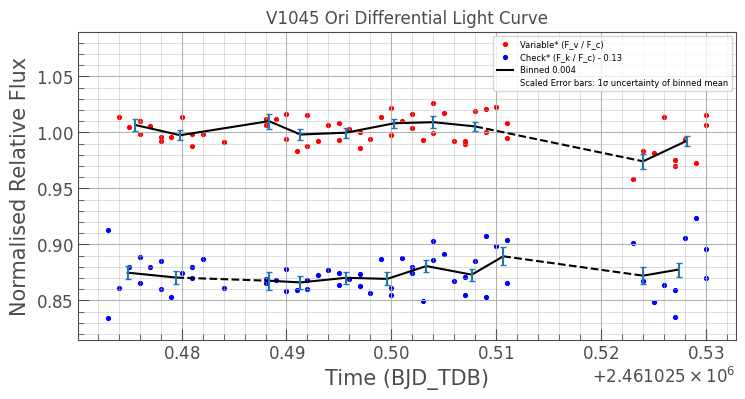

In [51]:
df = pd.read_csv("https://raw.githubusercontent.com/ag25-lgtm/Astrophotometry-Differential-Light-Curve/refs/heads/main/HJD_bjd_tdb_new2.csv") #Loads .csv file

time = df["BJD_TDB"] #extracts timestap column of Heliocentric julian data
v_mag = df["053454.0-040637"] #extracts magnitude measurments of target variable star
c_mag = df["053432.5-042915"] #extracts magnitude measurments of comparison star
k_mag = df["053459.0-042115"] #extracts magnitude measurments of check star

v_minus_c = v_mag - c_mag #subtracts comparision star mag from variable mag to find differential magnitude due to star variability
k_minus_c = k_mag - c_mag #subtracts comparision star from check star to ensure comparison star is non-variable (ideally constant)

#convert differential magnitude (log) into relative flux ratio (linear) by Pogson's Relation
rel_v_flux = 10 ** (-0.4 * v_minus_c) #calculate relative flux of variable star to comparision star
rel_k_flux = 10 ** (-0.4 * k_minus_c) #calculate relative flux of check star to comparision star

#Create LightKurve Objects
#Variable
lc_var = lk.LightCurve(
    time=time,
    flux=rel_v_flux,
    label="Variable* (F_v / F_c)"
) #varaible star flux/time object

lc_var_clean, v_mask = lc_var.remove_outliers(
    sigma=3,
    return_mask=True
) #removes outliers more than 3 sigma from the mean

lc_var_norm = lc_var_clean.normalize() #normalised

#Check
lc_check = lk.LightCurve(
    time=time,
    flux=rel_k_flux,
    label="Check* (F_k / F_c) - 0.13"
) #check star flux/time object

lc_check_clean, k_mask = lc_check.remove_outliers(
    sigma=3,
    return_mask=True
)

lc_check_norm = lc_check_clean.normalize() #normalised
lc_check_shift = lc_check_norm - 0.13

#print idx of clipped points
print(f"Variable star clipped indices: {np.where(v_mask)[0]}")
print(f"Check star clipped indices: {np.where(k_mask)[0]}")

#Error in each data point using SNR
v_snr = df["SNR_v"]
c_snr = df["SNR_c"]
k_snr = df["SNR_k"]

#apply mask to snr values
v_snr_clean = v_snr[~v_mask] # ~ flips bools to return every point which was NOT removed
c_snr_for_v = c_snr[~v_mask]

k_snr_clean = k_snr[~k_mask]
c_snr_for_k = c_snr[~k_mask]

#find normalised relative fluxes
v_norm_rel_flux = lc_var_norm.flux.value
k_norm_rel_flux = lc_check_norm.flux.value

#Propogate erros in relative flux, By Definition SNR=​F​/σ_F
v_rel_flux_err = v_norm_rel_flux * np.hypot(
    1 / v_snr_clean,
    1 / c_snr_for_v
) #variable rel flux error

k_rel_flux_err = k_norm_rel_flux * np.hypot(
    1 / k_snr_clean,
    1 / c_snr_for_k
) #check rel flux error

#Manually Bin and propogate errors for each bin (0.004 days)
bin_len = 0.004
#Define Variables
v_time = lc_var_norm.time.value #time values
v_flux = v_norm_rel_flux
v_err = v_rel_flux_err

k_time = lc_check_norm.time.value #time values
k_flux = k_norm_rel_flux - 0.13
k_err = k_rel_flux_err

#Split observations into bin numbers
v_bin = np.floor((v_time - lc_var_norm.time.value[0]) / bin_len) #time difference fromt he first data point
k_bin = np.floor((k_time - lc_check_shift.time.value[0]) / bin_len) #np.floor always rounds down

#Create containers to hold (time, flux, error) for each bin
v_binned = []
k_binned = []

#Loop through variables and check bins
for b in np.unique(v_bin): #unique(v_bin) find all bin numbers (b) in v bin
    mask = v_bin == b #creates a bool array of all the data points in a given bin (b = v_bin)
    flux = v_flux[mask] #used the bool mask to select only flux measurments in bin b
    err = v_err[mask] #same masking for error
    mean_flux = np.mean(flux)
    mean_err = np.sqrt(np.sum(err**2)) / len(err) #the error on the equally weighted mean of independent measurments
    mean_time = np.mean(v_time[mask])
    n_points = mask.sum() #tracks how many points went into this bin

    v_binned.append((mean_time, mean_flux, mean_err, n_points)) #adds the time, flux and erros to the previously defined containers

for b in np.unique(k_bin):
    mask = k_bin == b
    flux = k_flux[mask]
    err = k_err[mask]
    mean_flux = np.mean(flux)
    mean_err = np.sqrt(np.sum(err**2)) / len(err)
    mean_time = np.mean(k_time[mask])
    n_points = mask.sum()

    k_binned.append((mean_time, mean_flux, mean_err, n_points))

#Convert tuples into arrays and define variables
v_binned = np.array(v_binned)
v_binned = v_binned[~np.isnan(v_binned[:, 1])] #removes nans #isnan() keeps only non-nans

k_binned = np.array(k_binned)
k_binned = k_binned[~np.isnan(k_binned[:, 1])]

#minimum point per bin filter
min_points_per_bin = 3

n_v_before, n_k_before = len(v_binned), len(k_binned)
v_binned = v_binned[v_binned[:, 3] >= min_points_per_bin] #filters out bins with less than 3 data points
k_binned = k_binned[k_binned[:, 3] >= min_points_per_bin]
print(f"Variable: kept {len(v_binned)}/{n_v_before} bins (min {min_points_per_bin} pts/bin)") #prints the numbner of bins kept
print(f"Check: kept {len(k_binned)}/{n_k_before} bins (min {min_points_per_bin} pts/bin)") #prints the numbner of bins kept

#define variables
t_var = v_binned[:, 0] #raw time values
t_check = k_binned[:, 0]
f_var = v_binned[:, 1] #raw flux value
f_check = k_binned[:, 1]
err_var = v_binned[:, 2] #err value
err_check = k_binned[:, 2]

#check binned errors are similar
print(f'min_err_v: {np.round(np.min(err_v), 4)}, max_err_v: {np.round(np.max(err_v), 4)}')
print(f'min_err_k: {np.round(np.min(err_k), 4)}, max_err_k {np.round(np.max(err_k), 4)}')

#reduced chi**2 for variable star

#define variables
flux_v = v_binned[:, 1]
err_v = v_binned[:, 2]

#find mean flux
f_bar_v = np.mean(flux_v)

#find chi-squared
chi2_v = np.sum((flux_v - f_bar_v)**2 / err_v**2)

#Reduced chi2
chi2_red_v = chi2_v / (len(flux_v) -1)
print(f"Variable Star reduced chi^2 = {np.round(chi2_red_v, 2)}")

#reduced chi**2 for check star

#define variables
flux_k = k_binned[:, 1]
err_k = k_binned[:, 2]

#find mean flux
f_bar_k = np.mean(flux_k)

#find chi-squared
chi2_k = np.sum((flux_k - f_bar_k)**2 / err_k**2)

#Reduced chi2
chi2_red_k = chi2_k / (len(flux_k) -1)
print(f"Check Star reduced chi^2 = {np.round(chi2_red_k, 2)}")

#find p values for variable and check star
p_v = chi2.sf(chi2_v, len(flux_v) - 1) #calcualtes propability of obtaining a chi squared value ata least as large as the calcualted
p_k = chi2.sf(chi2_k, len(flux_k) - 1)

print(f"Variable Star p-value = {p_v}")
print(f"Check Star p-value = {p_k}")

# since check star is assumed constant resacle erros by sqrt(chi2_red_k)
scale_factor = np.sqrt(chi2_red_k)

err_var_scaled = err_var * scale_factor
err_check_scaled = err_check * scale_factor

#redo chi^2 and p test with scaled values
chi2_v_scaled = np.sum((f_var - np.mean(f_var))**2 / err_var_scaled**2)
chi2_red_v_scaled = chi2_v_scaled / (len(f_var) - 1)
p_v_scaled = chi2.sf(chi2_v_scaled, len(f_var) - 1)

chi2_k_scaled = np.sum((f_check - np.mean(f_check))**2 / err_check_scaled**2)
chi2_red_k_scaled = chi2_k_scaled / (len(f_check) - 1)
p_k_scaled = chi2.sf(chi2_k_scaled, len(f_check) - 1)

print(f"Rescaled Variable Star reduced chi^2 = {np.round(chi2_red_v_scaled, 2)}")
print(f"Rescaled Check Star reduced chi^2    = {np.round(chi2_red_k_scaled, 2)}")
print(f"Rescaled Variable Star p-value = {np.round(p_v_scaled, 6)}")
print(f"Rescaled Check Star p-value    = {np.round(p_k_scaled,3 )}")

#Plot Scatters on Single graph
var_graph = lc_var_norm.scatter(c='red', s=30) #create a scatter graph or the varaible flux/time object
lc_check_shift.scatter(ax=var_graph, c='blue', s=30) #scatter plots the check star flux/time on the same axes as variable

#Bridging Gaps Gaps in data
def plot_gapped_line(var_graph, time, flux, color='black', label=None): #Defines a reusable function that can be used to plot any time and flux values
    dt = np.diff(time) #calculates the time difference btween sucessive data points
    gap_thresh = 2 * np.median(dt) #set a threshold to be 2 * median gap
    gap_indices = np.where(dt > gap_thresh)[0] #evaluates teh data indices for which the threshold is met

    start_idx = 0 #first index is 0
    for idx in gap_indices:
        var_graph.plot(time[start_idx:idx + 1], flux[start_idx:idx + 1], color='black', linewidth=1.5, label=label) #plots solid lines from the start upto the gap index
        var_graph.plot(time[idx:idx + 2], flux[idx:idx + 2], linestyle='--', color='black', linewidth=1.5, label=None) #plots dashed line from idx to idx +1
        start_idx = idx + 1 # repeats for the next point after the gap
    var_graph.plot(time[start_idx:], flux[start_idx:], color='black', linewidth=1.5) #plot solid line from end of last gap idx to end of plot

#Call the defined function for the variable and check star
plot_gapped_line(var_graph, t_var, f_var, label="Binned 0.004")
plot_gapped_line(var_graph, t_check, f_check)

#Label Axes, gridlines etc
var_graph.set(
    xlabel="Time (BJD_TDB)",
    ylabel="Normalised Relative Flux",
    title="V1045 Ori Differential Light Curve"
)
var_graph.set_ylim(0.815, 1.09)
var_graph.plot([], [], ' ', label='Scaled Error bars: 1σ uncertainty of binned mean')

#assigned scaled error bars and plot
plt.errorbar(
    t_var,
    f_var,
    yerr=err_var_scaled,
    fmt='none',
    capsize=2
)

plt.errorbar(
    t_check,
    f_check,
    yerr=err_check_scaled,
    fmt='none',
    capsize=2
)

plt.grid(True, which='major', linestyle="-", linewidth=0.75, alpha=1)
plt.grid(True, which='minor', linestyle="-", linewidth=0.75, alpha=0.4)

plt.legend(loc="upper right", fontsize=6)
plt.savefig("lightcurve.png", dpi=300)
#files.download("lightcurve.png")
plt.show()